## Hyperparameter Tuning and Model Evaluation Report

### Team Rho

###### Brendan Collari and J. Casey Brookshier 

In [3]:
import os
print(os.getcwd())

/Users/brendan/Documents/DSE6214/Team-Rho-Capstone-Project/Notebooks/raw


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

#load preprocessed train/test data same as baseline model

DATA_DIR = Path("../../Data/processed/Engineered_Data_v2")

train = pd.read_csv(DATA_DIR / "team_rho_train_preprocessed_engineered_v2.csv")
test = pd.read_csv(DATA_DIR / "team_rho_test_preprocessed_engineered_v2.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (227, 9)
Test shape: (133, 9)


,State,Year,admission_rate_per_100k,admission_rate_lag2,neighbor_admission_rate_lag1,search_PC1,search_PC2,search_PC3,log_state_population
0,Alaska,2017,303.650691,297.929391,394.821026,-4.362284,-0.868199,-0.377299,13.515733
1,Alaska,2018,319.023002,289.533044,407.012291,-4.243584,-0.623294,-0.459835,13.509833
2,Alaska,2019,333.968100,303.650691,408.686371,-3.918116,-0.194698,-1.192840,13.505723
3,Alaska,2020,348.761827,319.023002,410.772841,-3.797099,-0.049901,-1.278749,13.502385
4,Arizona,2016,205.910436,223.530133,340.205703,0.978794,-0.049951,1.845417,15.753499


In [5]:
#define predictors and target
#state is label-encoded for tree-based models since Random Forest/XGBoost don't require dummy encoding 
#year is excluded to avoid temporal leakage, consistent with the baseline model.

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train["State_encoded"] = le.fit_transform(train["State"])
test["State_encoded"] = le.transform(test["State"])

feature_cols = [
    "State_encoded", "admission_rate_lag2", "neighbor_admission_rate_lag1",
    "search_PC1", "search_PC2", "search_PC3", "log_state_population"
]
target_col = "admission_rate_per_100k"

X_train, y_train = train[feature_cols], train[target_col]
X_test, y_test = test[feature_cols], test[target_col]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (227, 7)
X_test shape: (133, 7)


In [6]:
#Randome forest model default, time series cross validation

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf = RandomForestRegressor(random_state=42)

tscv = TimeSeriesSplit(n_splits=5)
rf_cv_rmse = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    rf.fit(X_tr, y_tr)
    preds = rf.predict(X_val)
    fold_rmse = np.sqrt(mean_squared_error(y_val, preds))
    rf_cv_rmse.append(fold_rmse)
    print(f"Fold {fold}: RMSE = {fold_rmse:.2f}")

print(f"\nMean CV RMSE: {np.mean(rf_cv_rmse):.2f}")
print(f"Std CV RMSE: {np.std(rf_cv_rmse):.2f}")

Fold 1: RMSE = 131.71
Fold 2: RMSE = 96.66
Fold 3: RMSE = 68.46
Fold 4: RMSE = 56.70
Fold 5: RMSE = 47.04

Mean CV RMSE: 80.11
Std CV RMSE: 30.71


In [7]:
#fit it on full training set then will evaluate on train and test
rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

print("Random Forestv1")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, rf_train_pred)):.2f}")
print(f"Train MAE: {mean_absolute_error(y_train, rf_train_pred):.2f}")
print(f"Train R squared: {r2_score(y_train, rf_train_pred):.3f}")
print()
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, rf_test_pred)):.2f}")
print(f"Test MAE: {mean_absolute_error(y_test, rf_test_pred):.2f}")
print(f"Test R squared: {r2_score(y_test, rf_test_pred):.3f}")

Random Forestv1
Train RMSE: 23.88
Train MAE: 13.44
Train R squared: 0.975

Test RMSE: 39.59
Test MAE: 29.90
Test R squared: 0.908


In [9]:
import sys
!{sys.executable} -m pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 23.6 MB/s  0:00:00

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /Users/brendan/my_env/bin/python3.11 -m pip install --upgrade pip


In [8]:
#XGBoost default, time-series cross-validation

from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)

xgb_cv_rmse = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    xgb.fit(X_tr, y_tr)
    preds = xgb.predict(X_val)
    fold_rmse = np.sqrt(mean_squared_error(y_val, preds))
    xgb_cv_rmse.append(fold_rmse)
    print(f"Fold {fold}: RMSE = {fold_rmse:.2f}")

print(f"\nMean CV RMSE: {np.mean(xgb_cv_rmse):.2f}")
print(f"Std CV RMSE: {np.std(xgb_cv_rmse):.2f}")

Fold 1: RMSE = 147.97
Fold 2: RMSE = 117.02
Fold 3: RMSE = 76.75
Fold 4: RMSE = 63.24
Fold 5: RMSE = 45.21

Mean CV RMSE: 90.04
Std CV RMSE: 37.39


In [9]:
#fit on full training set and evaluate both train and test
xgb.fit(X_train, y_train)

xgb_train_pred = xgb.predict(X_train)
xgb_test_pred = xgb.predict(X_test)

print("XGBoostv1 ")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, xgb_train_pred)):.2f}")
print(f"Train MAE: {mean_absolute_error(y_train, xgb_train_pred):.2f}")
print(f"Train R squared: {r2_score(y_train, xgb_train_pred):.3f}")
print()
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, xgb_test_pred)):.2f}")
print(f"Test MAE: {mean_absolute_error(y_test, xgb_test_pred):.2f}")
print(f"Test Rsquared: {r2_score(y_test, xgb_test_pred):.3f}")

XGBoostv1 
Train RMSE: 0.06
Train MAE: 0.04
Train R squared: 1.000

Test RMSE: 46.66
Test MAE: 36.82
Test Rsquared: 0.873


In [10]:
#comparison between deafult XGBoost and Random Forest

comparison = pd.DataFrame({
    "Model": ["MLR Baseline", "Random Forest (default)", "XGBoost (default)"],
    "Train RMSE": [38.04, 23.88, 0.06],
    "Test RMSE": [53.98, 39.59, 46.66],
    "Train R2": [0.936, 0.975, 1.000],
    "Test R2": [0.829, 0.908, 0.873],
    "CV Mean RMSE": [72.88, 80.11, 90.04],
    "CV Std RMSE": [52.03, 30.71, 37.39]
})

comparison

,Model,Train RMSE,Test RMSE,Train R2,Test R2,CV Mean RMSE,CV Std RMSE
0,MLR Baseline,38.04,53.98,0.936,0.829,72.88,52.03
1,Random Forest (default),23.88,39.59,0.975,0.908,80.11,30.71
2,XGBoost (default),0.06,46.66,1.000,0.873,90.04,37.39


In [11]:
#Random Forest hyperparameter tuning now
#Tuning n_estimators, max_depth, min_samples_leaf, and max_features to control overfitting seen in the default XGBoost run 
#hope to improve generalization for Random Forest 
#Use the same TimeSeriesSplit CV as baseline and defaults 

from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, None],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=rf_param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best params:", rf_grid.best_params_)
print("Best CV RMSE:", -rf_grid.best_score_)

Best params: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 4, 'n_estimators': 300}
Best CV RMSE: 76.8334692373481


In [12]:
#eval tuned Random Forest on train/test
rf_tuned = rf_grid.best_estimator_

rf_tuned_train_pred = rf_tuned.predict(X_train)
rf_tuned_test_pred = rf_tuned.predict(X_test)

print("Random Forestv2")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, rf_tuned_train_pred)):.2f}")
print(f"Train MAE: {mean_absolute_error(y_train, rf_tuned_train_pred):.2f}")
print(f"Train Rsquared: {r2_score(y_train, rf_tuned_train_pred):.3f}")
print()
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, rf_tuned_test_pred)):.2f}")
print(f"Test MAE: {mean_absolute_error(y_test, rf_tuned_test_pred):.2f}")
print(f"Test Rsquared: {r2_score(y_test, rf_tuned_test_pred):.3f}")

Random Forestv2
Train RMSE: 39.73
Train MAE: 22.83
Train Rsquared: 0.930

Test RMSE: 40.31
Test MAE: 30.29
Test Rsquared: 0.905


In [13]:
#XGBoost hyperparameter tuning
# Default XGBoost showed overfitting max_depth
#learning_rate, n_estimators, and regularization terms are tuned to constrain model complexity.

xgb_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.05, 0.1],
    "reg_alpha": [0, 0.5, 1],
    "reg_lambda": [1, 2, 5]
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid=xgb_param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best params:", xgb_grid.best_params_)
print("Best CV RMSE:", -xgb_grid.best_score_)

Best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 5}
Best CV RMSE: 84.99531531736109


In [14]:
#eval XGBoost on train/test
xgb_tuned = xgb_grid.best_estimator_

xgb_tuned_train_pred = xgb_tuned.predict(X_train)
xgb_tuned_test_pred = xgb_tuned.predict(X_test)

print("XGBoostv2")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, xgb_tuned_train_pred)):.2f}")
print(f"Train MAE: {mean_absolute_error(y_train, xgb_tuned_train_pred):.2f}")
print(f"Train Rsquared: {r2_score(y_train, xgb_tuned_train_pred):.3f}")
print()
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, xgb_tuned_test_pred)):.2f}")
print(f"Test MAE: {mean_absolute_error(y_test, xgb_tuned_test_pred):.2f}")
print(f"Test R squared: {r2_score(y_test, xgb_tuned_test_pred):.3f}")

XGBoostv2
Train RMSE: 44.04
Train MAE: 29.82
Train Rsquared: 0.914

Test RMSE: 40.04
Test MAE: 31.52
Test R squared: 0.906


In [15]:
# full comaprsion for 5 models created
comparison = pd.DataFrame({
    "Model": [
        "MLR Baseline", 
        "Random Forest (default)", "Random Forest (tuned)",
        "XGBoost (default)", "XGBoost (tuned)"
    ],
    "Train RMSE": [38.04, 23.88, 39.73, 0.06, 44.04],
    "Test RMSE":  [53.98, 39.59, 40.31, 46.66, 40.04],
    "Train R2":   [0.936, 0.975, 0.930, 1.000, 0.914],
    "Test R2":    [0.829, 0.908, 0.905, 0.873, 0.906],
})

comparison

,Model,Train RMSE,Test RMSE,Train R2,Test R2
0,MLR Baseline,38.04,53.98,0.936,0.829
1,Random Forest (default),23.88,39.59,0.975,0.908
2,Random Forest (tuned),39.73,40.31,0.930,0.905
3,XGBoost (default),0.06,46.66,1.000,0.873
4,XGBoost (tuned),44.04,40.04,0.914,0.906


In [22]:
import sys
!{sys.executable} -m pip install lightgbm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 17.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [lightgbm]1/2 [lightgbm]

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /Users/brendan/my_env/bin/python3.11 -m pip install --upgrade pip


In [16]:
#LightGBM 
#directly compare gradient boosting implementations

from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(random_state=42)

lgbm_cv_rmse = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    lgbm.fit(X_tr, y_tr)
    preds = lgbm.predict(X_val)
    fold_rmse = np.sqrt(mean_squared_error(y_val, preds))
    lgbm_cv_rmse.append(fold_rmse)
    print(f"Fold {fold}: RMSE = {fold_rmse:.2f}")

print(f"\nMean CV RMSE: {np.mean(lgbm_cv_rmse):.2f}")
print(f"Std CV RMSE: {np.std(lgbm_cv_rmse):.2f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000084 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 92
[LightGBM] [Info] Number of data points in the train set: 42, number of used features: 6
[LightGBM] [Info] Start training from score 316.244556
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [17]:
#LightGBM on full training set and eval
lgbm.fit(X_train, y_train)

lgbm_train_pred = lgbm.predict(X_train)
lgbm_test_pred = lgbm.predict(X_test)

print("LightGBMv1")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, lgbm_train_pred)):.2f}")
print(f"Train MAE: {mean_absolute_error(y_train, lgbm_train_pred):.2f}")
print(f"Train Rsquared: {r2_score(y_train, lgbm_train_pred):.3f}")
print()
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, lgbm_test_pred)):.2f}")
print(f"Test MAE: {mean_absolute_error(y_test, lgbm_test_pred):.2f}")
print(f"Test Rsquared: {r2_score(y_test, lgbm_test_pred):.3f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000063 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 508
[LightGBM] [Info] Number of data points in the train set: 227, number of used features: 7
[LightGBM] [Info] Start training from score 403.515019
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

In [18]:
#LightGBM hyperparameter tuning
#small training set so tune on constraining model complexity and learning_rate and n_estimators.

lgbm_param_grid = {
    "n_estimators": [50, 100, 200],
    "num_leaves": [7, 15, 31],
    "max_depth": [3, 5, -1],
    "learning_rate": [0.01, 0.05, 0.1],
    "min_child_samples": [5, 10, 20]
}

lgbm_grid = GridSearchCV(
    LGBMRegressor(random_state=42, verbose=-1),
    param_grid=lgbm_param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

lgbm_grid.fit(X_train, y_train)

print("Best params:", lgbm_grid.best_params_)
print("Best CV RMSE:", -lgbm_grid.best_score_)

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_samples': 10, 'n_estimators': 50, 'num_leaves': 15}
Best CV RMSE: 87.83144354430787


In [19]:
#eval LightGBM on train/test
lgbm_tuned = lgbm_grid.best_estimator_

lgbm_tuned_train_pred = lgbm_tuned.predict(X_train)
lgbm_tuned_test_pred = lgbm_tuned.predict(X_test)

print("LightGBMv2")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, lgbm_tuned_train_pred)):.2f}")
print(f"Train MAE: {mean_absolute_error(y_train, lgbm_tuned_train_pred):.2f}")
print(f"Train Rsquared: {r2_score(y_train, lgbm_tuned_train_pred):.3f}")
print()
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, lgbm_tuned_test_pred)):.2f}")
print(f"Test MAE: {mean_absolute_error(y_test, lgbm_tuned_test_pred):.2f}")
print(f"Test Rsquared: {r2_score(y_test, lgbm_tuned_test_pred):.3f}")

LightGBMv2
Train RMSE: 48.15
Train MAE: 32.56
Train Rsquared: 0.898

Test RMSE: 40.64
Test MAE: 32.46
Test Rsquared: 0.903


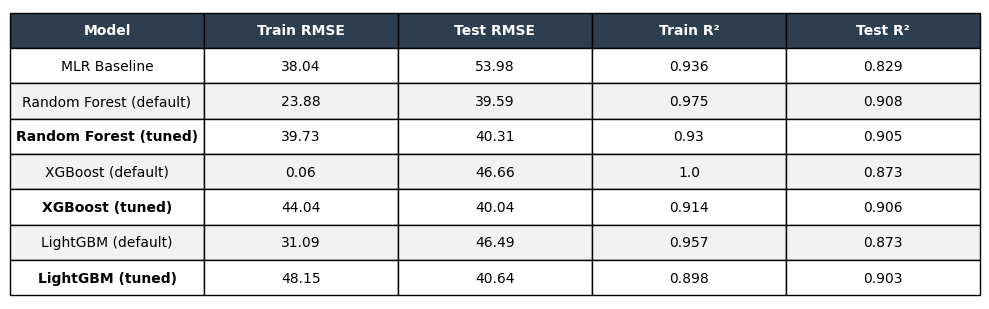

In [20]:

#Table 1 comparison table

comparison = pd.DataFrame({
    "Model": ["MLR Baseline", "Random Forest (default)", "Random Forest (tuned)",
              "XGBoost (default)", "XGBoost (tuned)", "LightGBM (default)", "LightGBM (tuned)"],
    "Train RMSE": [38.04, 23.88, 39.73, 0.06, 44.04, 31.09, 48.15],
    "Test RMSE": [53.98, 39.59, 40.31, 46.66, 40.04, 46.49, 40.64],
    "Train R²": [0.936, 0.975, 0.930, 1.000, 0.914, 0.957, 0.898],
    "Test R²": [0.829, 0.908, 0.905, 0.873, 0.906, 0.873, 0.903],
})

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.axis('off')
tbl = ax.table(cellText=comparison.values, colLabels=comparison.columns,
                cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.8)

for j in range(len(comparison.columns)):
    tbl[(0, j)].set_facecolor('#2c3e50')
    tbl[(0, j)].set_text_props(color='white', weight='bold')

for i in range(1, len(comparison) + 1):
    if i % 2 == 0:
        for j in range(len(comparison.columns)):
            tbl[(i, j)].set_facecolor('#f2f2f2')
    if 'tuned' in str(comparison.iloc[i-1, 0]).lower():
        tbl[(i, 0)].set_text_props(weight='bold')

plt.tight_layout()
plt.show()

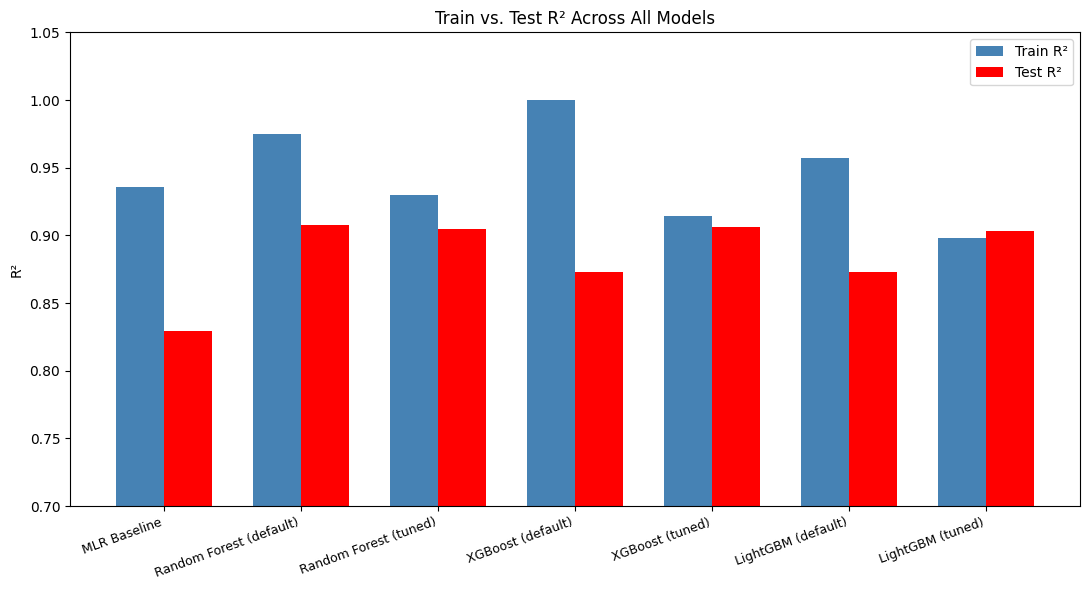

In [21]:
#Train/Test Rsquared across all models 

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width/2, comparison["Train R²"], width, label="Train R²", color="steelblue")
ax.bar(x + width/2, comparison["Test R²"], width, label="Test R²", color="red")
ax.set_xticks(x)
ax.set_xticklabels(comparison["Model"], fontsize=9, rotation=20, ha='right')
ax.set_ylabel("R²")
ax.set_title("Train vs. Test R² Across All Models")
ax.legend()
ax.set_ylim(0.7, 1.05)
plt.tight_layout()
plt.show()

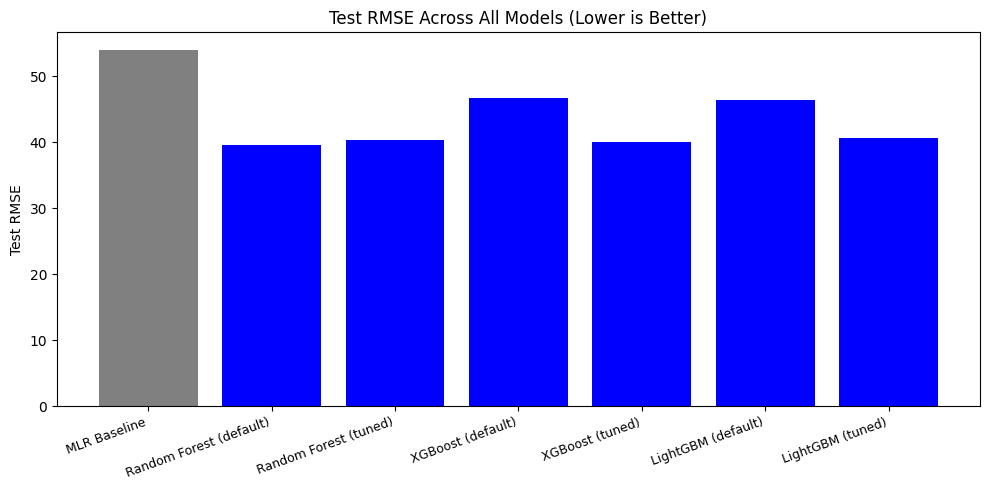

In [22]:
#Test RMSE across all models

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['gray' if 'Baseline' in m else 'blue' for m in comparison["Model"]]
ax.bar(comparison["Model"], comparison["Test RMSE"], color=colors)
ax.set_ylabel("Test RMSE")
ax.set_title("Test RMSE Across All Models (Lower is Better)")
plt.xticks(fontsize=9, rotation=20, ha='right')
plt.tight_layout()
plt.show()

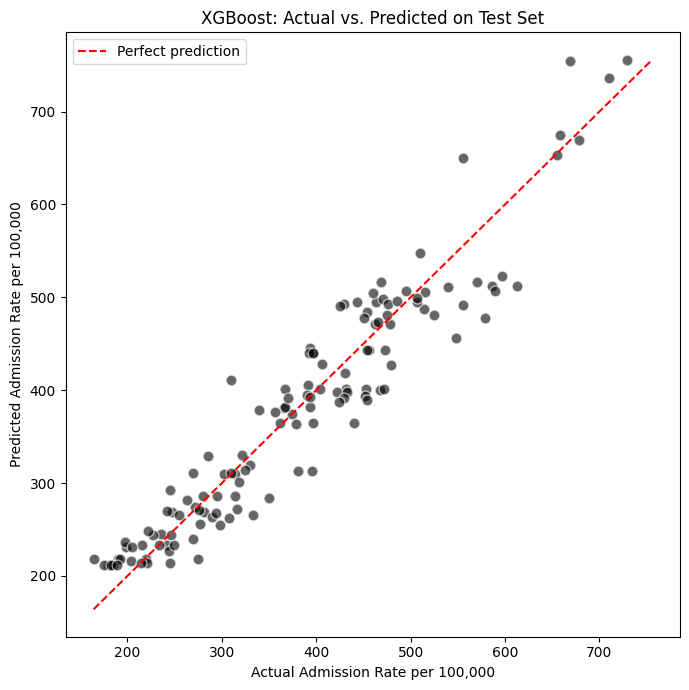

In [23]:
#Actual vs. Predicted for XGBoost tuned on test set

xgb_tuned_test_pred = xgb_tuned.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, xgb_tuned_test_pred, alpha=0.6, color='black', edgecolor='white', s=60)
lims = [min(y_test.min(), xgb_tuned_test_pred.min()), max(y_test.max(), xgb_tuned_test_pred.max())]
ax.plot(lims, lims, 'r--', label='Perfect prediction')
ax.set_xlabel('Actual Admission Rate per 100,000')
ax.set_ylabel('Predicted Admission Rate per 100,000')
ax.set_title('XGBoost: Actual vs. Predicted on Test Set')
ax.legend()
plt.tight_layout()
plt.show()

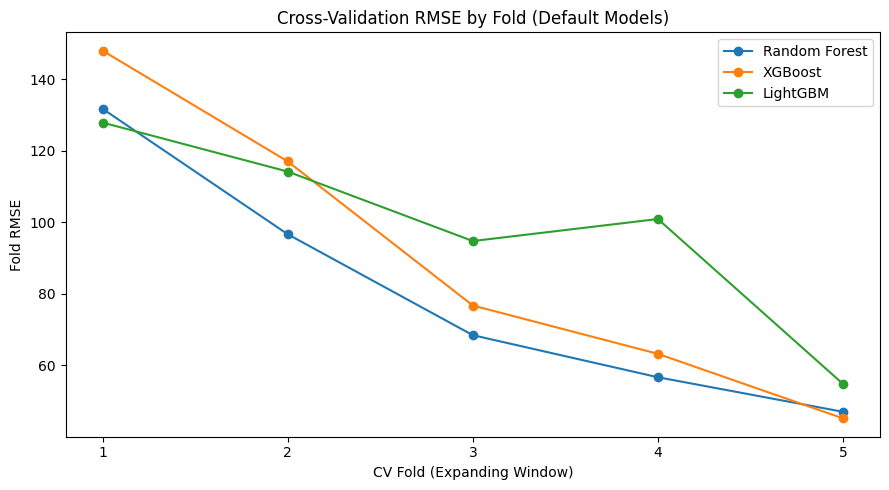

In [24]:
# Graph 5: Cross-validation RMSE by fold (default models)

fold_data = {
    'Random Forest': rf_cv_rmse,
    'XGBoost': xgb_cv_rmse,
    'LightGBM': lgbm_cv_rmse
}

fig, ax = plt.subplots(figsize=(9, 5))
for name, vals in fold_data.items():
    ax.plot(range(1, 6), vals, marker='o', label=name)
ax.set_xlabel('CV Fold (Expanding Window)')
ax.set_ylabel('Fold RMSE')
ax.set_title('Cross-Validation RMSE by Fold (Default Models)')
ax.set_xticks(range(1, 6))
ax.legend()
plt.tight_layout()
plt.show()

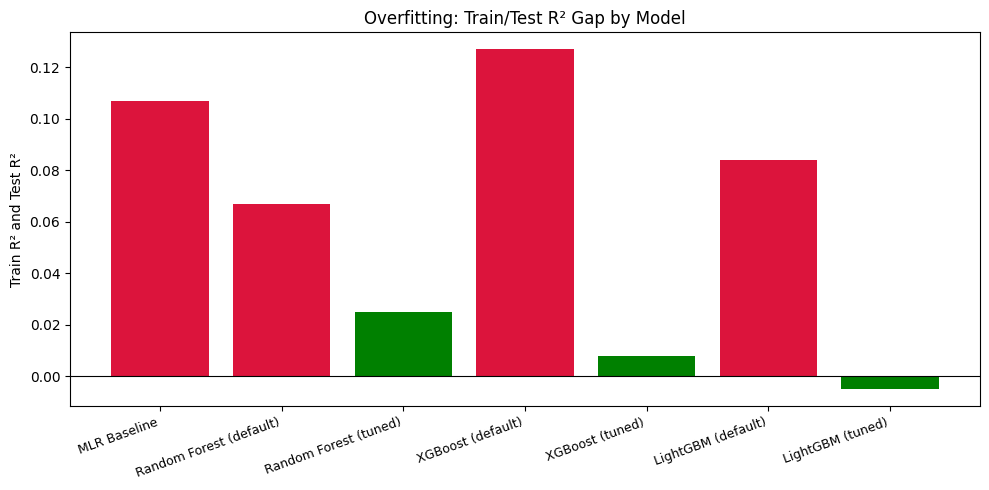

In [25]:
#Train-Test R² gap across all models to show overfitting 

comparison["R2_Gap"] = comparison["Train R²"] - comparison["Test R²"]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['crimson' if g > 0.05 else 'green' for g in comparison["R2_Gap"]]
ax.bar(comparison["Model"], comparison["R2_Gap"], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel("Train R² and Test R²")
ax.set_title("Overfitting: Train/Test R² Gap by Model")
plt.xticks(fontsize=9, rotation=20, ha='right')
plt.tight_layout()
plt.show()

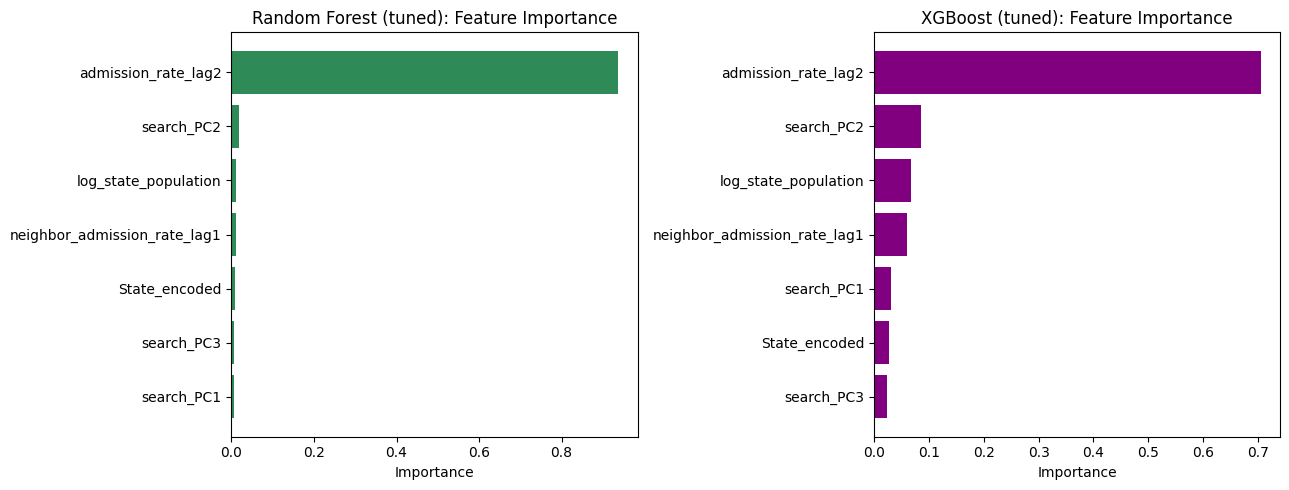

In [26]:
#Feature importance comparison for random forest and XGB

rf_importance = pd.Series(rf_tuned.feature_importances_, index=feature_cols).sort_values()
xgb_importance = pd.Series(xgb_tuned.feature_importances_, index=feature_cols).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(rf_importance.index, rf_importance.values, color='seagreen')
axes[0].set_title('Random Forest (tuned): Feature Importance')
axes[0].set_xlabel('Importance')

axes[1].barh(xgb_importance.index, xgb_importance.values, color='purple')
axes[1].set_title('XGBoost (tuned): Feature Importance')
axes[1].set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [41]:
import sys
!{sys.executable} -m pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.1/565.1 kB 6.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 MB 29.6 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 26.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 34.1 MB/s  0:00:00m0:00:01
  Attempting uninstall: numpy90m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/7 [slicer]
    Found existing installation: numpy 1.26.4━━━━━━━━━━━━━━━━━ 1/7 [slicer]
    Uninstalling numpy-1.26.4:━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/7 [numpy]
      Successfully uninstalled numpy-1.26.4━━━━━━━━━━━━━━━━━━━ 2/7 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [shap]6/7 [shap]]ickle]

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /Users/brendan/my_env/bin/python3.11 -m pip install --upgrade pip


In [27]:
#SHAP: Model interpretation for XGBoost (tuned).

import shap

explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)

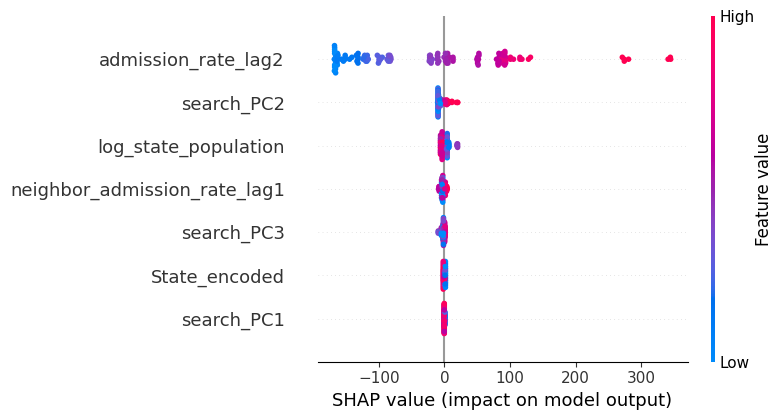

In [28]:
#SHAP summary show direction and magnitude of each feature's effect across all test observations
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

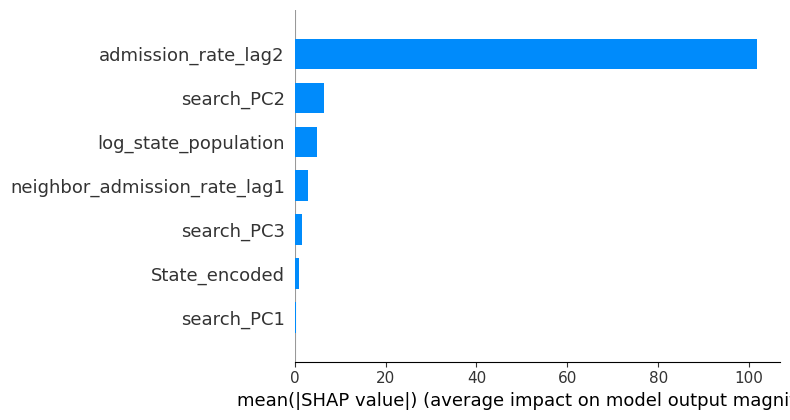

In [29]:
#SHAP summary but bar 
#mean absolute SHAP value per feature for more feature importance
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

In [30]:
#ablation study with vs. without Google Trends features

#tests how much predictive value the Google Trends-derived PCA components (search_PC1-3) contribute 
#refit RF and XGBoost using the same tuned hyperparameters once with all 7 features and once with the 3 PCA components removed

no_trends_features = [
    "State_encoded", "admission_rate_lag2",
    "neighbor_admission_rate_lag1", "log_state_population"
]

X_train_nt = train[no_trends_features]
X_test_nt = test[no_trends_features]

#Random Forest
rf_nt = RandomForestRegressor(
    max_depth=None, max_features=None,
    min_samples_leaf=4, n_estimators=300, random_state=42
)
rf_nt.fit(X_train_nt, y_train)
rf_nt_pred = rf_nt.predict(X_test_nt)

#XGBoost
xgb_nt = XGBRegressor(
    learning_rate=0.05, max_depth=2, n_estimators=100,
    reg_alpha=0, reg_lambda=5, random_state=42
)
xgb_nt.fit(X_train_nt, y_train)
xgb_nt_pred = xgb_nt.predict(X_test_nt)

print("No Google Trends")
print(f"RF  - Test RMSE: {np.sqrt(mean_squared_error(y_test, rf_nt_pred)):.2f} | Test R²: {r2_score(y_test, rf_nt_pred):.3f}")
print(f"XGB - Test RMSE: {np.sqrt(mean_squared_error(y_test, xgb_nt_pred)):.2f} | Test R²: {r2_score(y_test, xgb_nt_pred):.3f}")
print()
print("Has Google Trends")
print(f"RF  - Test RMSE: 40.31 | Test R²: 0.905")
print(f"XGB - Test RMSE: 40.04 | Test R²: 0.906")

No Google Trends
RF  - Test RMSE: 40.07 | Test R²: 0.906
XGB - Test RMSE: 39.67 | Test R²: 0.908

Has Google Trends
RF  - Test RMSE: 40.31 | Test R²: 0.905
XGB - Test RMSE: 40.04 | Test R²: 0.906
